# Molecular Graph Learning Curve

This notebook measures how predictive performance on the MoleculeNet HIV dataset changes as the number of training graphs increases, using `NSPPK` features with `radius=1`, `distance=4`, `connector=1` and a linear `SGDClassifier`.

The evaluation uses one fixed stratified train/test split. For each training-set size, the model is refit on several random subsets of the training pool and evaluated on the same held-out test set.


In [15]:
from pathlib import Path
import sys
import time

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from rdkit import RDLogger
from sklearn.linear_model import SGDClassifier
from sklearn.metrics import average_precision_score, roc_auc_score
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline

REPO_CANDIDATES = [Path.cwd().resolve(), Path.cwd().resolve().parent]
REPO_ROOT = next(candidate for candidate in REPO_CANDIDATES if (candidate / 'src').exists())
SRC_DIR = REPO_ROOT / 'src'
if str(SRC_DIR) not in sys.path:
    sys.path.insert(0, str(SRC_DIR))

from nsppk import NSPPK
from utils import plot_series_with_band_loess

DATASET_URL = 'https://deepchemdata.s3-us-west-1.amazonaws.com/datasets/HIV.csv'

NBIT = 14
RADIUS = 1
DISTANCE = 4
CONNECTOR = 1
LIMIT = 8000
BALANCE_DATASET = True
TRAIN_FRACTION = 0.7
TEST_SIZE = 1 - TRAIN_FRACTION
TRAIN_SIZE_VALUES = [250, 500, 1000, 2000, 4000]
N_REPEATS = 3
PARALLEL = True
RANDOM_STATE = 42

RDLogger.DisableLog('rdApp.*')



## Load molecular graphs

The notebook uses `NSPPK.load_from(...)` to parse the dataset. The HIV activity label is recovered from the second CSV column, which the built-in SMILES reader stores in `graph.graph['name']`.


In [2]:
loader = NSPPK(radius=RADIUS, distance=DISTANCE, connector=CONNECTOR, nbits=NBIT, parallel=PARALLEL)
graphs = loader.load_from(
    DATASET_URL,
    'smiles',
    limit=LIMIT,
    random_state=RANDOM_STATE,
    balance=BALANCE_DATASET,
    label_extractor=lambda graph: int(graph.graph['HIV_active']),
)
labels = np.asarray([int(graph.graph['HIV_active']) for graph in graphs])

original_dataset_size = len(loader.load_from(DATASET_URL, 'smiles'))
print('original loaded molecules:', original_dataset_size)
print('molecules used:', len(graphs))
print('positive rate:', labels.mean())


original loaded molecules: 41120
molecules used: 8000
positive rate: 0.180375


## Fixed train/test split

One stratified split is reused across all training-set sizes so the learning curve isolates the effect of training-set size rather than a changing test set.


In [ ]:
train_idx, test_idx = train_test_split(
    np.arange(len(graphs)),
    test_size=TEST_SIZE,
    stratify=labels,
    random_state=RANDOM_STATE,
)

train_graphs_full = [graphs[i] for i in train_idx]
test_graphs = [graphs[i] for i in test_idx]
y_train_full = labels[train_idx]
y_test = labels[test_idx]

train_size_values = [n for n in TRAIN_SIZE_VALUES if n <= len(train_graphs_full)]
if train_size_values[-1] != len(train_graphs_full):
    train_size_values.append(len(train_graphs_full))

print('train graphs:', len(train_graphs_full))
print('test graphs:', len(test_graphs))
print(f'train positive rate: {y_train_full.mean():.3f}')
print(f'test positive rate: {y_test.mean():.3f}')
print('train sizes:', train_size_values)


train graphs: 5599
test graphs: 2401
train positive rate: 0.1803893552420075
test positive rate: 0.180341524364848
train sizes: [250, 500, 1000, 2000, 4000, 5599]


## Run the learning curve

For each training-set size, this cell samples stratified subsets from the training pool, fits a scikit-learn `Pipeline([('nsppk', NSPPK(...)), ('classifier', SGDClassifier(...))])`, and evaluates ROC-AUC and average precision on the fixed test set.


In [4]:
results = []

print(f"{'train':>8} | {'repeat':>6} | {'roc_auc':>8} | {'avg_prec':>8} | {'seconds':>8}")
print('-' * 58)

for train_size in train_size_values:
    subset_roc_auc = []
    subset_avg_precision = []
    subset_runtime = []

    for repeat_idx in range(1, N_REPEATS + 1):
        if train_size == len(train_graphs_full):
            subset_local_idx = np.arange(len(train_graphs_full))
        else:
            subset_local_idx, _ = train_test_split(
                np.arange(len(train_graphs_full)),
                train_size=train_size,
                stratify=y_train_full,
                random_state=RANDOM_STATE + 1000 * repeat_idx + train_size,
            )

        subset_graphs = [train_graphs_full[i] for i in subset_local_idx]
        y_subset = y_train_full[subset_local_idx]

        pipeline = Pipeline([
            ('nsppk', NSPPK(
                radius=RADIUS,
                distance=DISTANCE,
                connector=CONNECTOR,
                nbits=NBIT,
                dense=False,
                parallel=PARALLEL,
            )),
            ('classifier', SGDClassifier(
                loss='log_loss',
                alpha=1e-5,
                penalty='l2',
                max_iter=2000,
                tol=1e-3,
                random_state=RANDOM_STATE,
            )),
        ])

        t0 = time.perf_counter()
        pipeline.fit(subset_graphs, y_subset)
        y_score = pipeline.decision_function(test_graphs)
        runtime_sec = time.perf_counter() - t0

        roc_auc = roc_auc_score(y_test, y_score)
        avg_precision = average_precision_score(y_test, y_score)

        subset_roc_auc.append(float(roc_auc))
        subset_avg_precision.append(float(avg_precision))
        subset_runtime.append(float(runtime_sec))

        print(f"{train_size:>8d} | {repeat_idx:>6d} | {roc_auc:>8.4f} | {avg_precision:>8.4f} | {runtime_sec:>8.2f}")

    results.append(
        {
            'train_size': train_size,
            'mean_roc_auc': float(np.mean(subset_roc_auc)),
            'std_roc_auc': float(np.std(subset_roc_auc, ddof=0)),
            'mean_avg_precision': float(np.mean(subset_avg_precision)),
            'std_avg_precision': float(np.std(subset_avg_precision, ddof=0)),
            'mean_runtime_sec': float(np.mean(subset_runtime)),
            'std_runtime_sec': float(np.std(subset_runtime, ddof=0)),
            'nbits': NBIT,
            'radius': RADIUS,
            'distance': DISTANCE,
            'connector': CONNECTOR,
        }
    )

results_df = pd.DataFrame(results)
results_df


   train | repeat |  roc_auc | avg_prec |  seconds
----------------------------------------------------------
     250 |      1 |   0.6812 |   0.4534 |    28.13
     250 |      2 |   0.6683 |   0.4350 |    30.27
     250 |      3 |   0.6316 |   0.3878 |    27.70
     500 |      1 |   0.6990 |   0.4630 |    30.52
     500 |      2 |   0.7043 |   0.4791 |    31.15
     500 |      3 |   0.7189 |   0.5012 |    31.49
    1000 |      1 |   0.7477 |   0.5118 |    36.84
    1000 |      2 |   0.7461 |   0.5571 |    34.42
    1000 |      3 |   0.7765 |   0.5760 |    35.75
    2000 |      1 |   0.7775 |   0.5523 |    45.10
    2000 |      2 |   0.7717 |   0.5211 |    43.58
    2000 |      3 |   0.7748 |   0.5609 |    44.33
    4000 |      1 |   0.7995 |   0.6131 |    63.24
    4000 |      2 |   0.7913 |   0.6023 |    60.24
    4000 |      3 |   0.8006 |   0.6321 |    60.96
    5599 |      1 |   0.8136 |   0.6467 |    78.71
    5599 |      2 |   0.8136 |   0.6467 |    80.77
    5599 |      3 |   0

,train_size,mean_roc_auc,std_roc_auc,mean_avg_precision,std_avg_precision,mean_runtime_sec,std_runtime_sec,nbits,radius,distance,connector
0,250,0.660381,0.021001,0.425394,0.027597,28.698569,1.124522,14,1,4,1
1,500,0.707411,0.008413,0.481107,0.015649,31.054037,0.403053,14,1,4,1
2,1000,0.756776,0.013983,0.548311,0.026923,35.670633,0.987568,14,1,4,1
3,2000,0.774686,0.002372,0.544772,0.017089,44.338882,0.618187,14,1,4,1
4,4000,0.797168,0.004147,0.615845,0.012339,61.479461,1.280805,14,1,4,1
5,5599,0.813647,0.000000,0.646733,0.000000,78.130002,2.424362,14,1,4,1


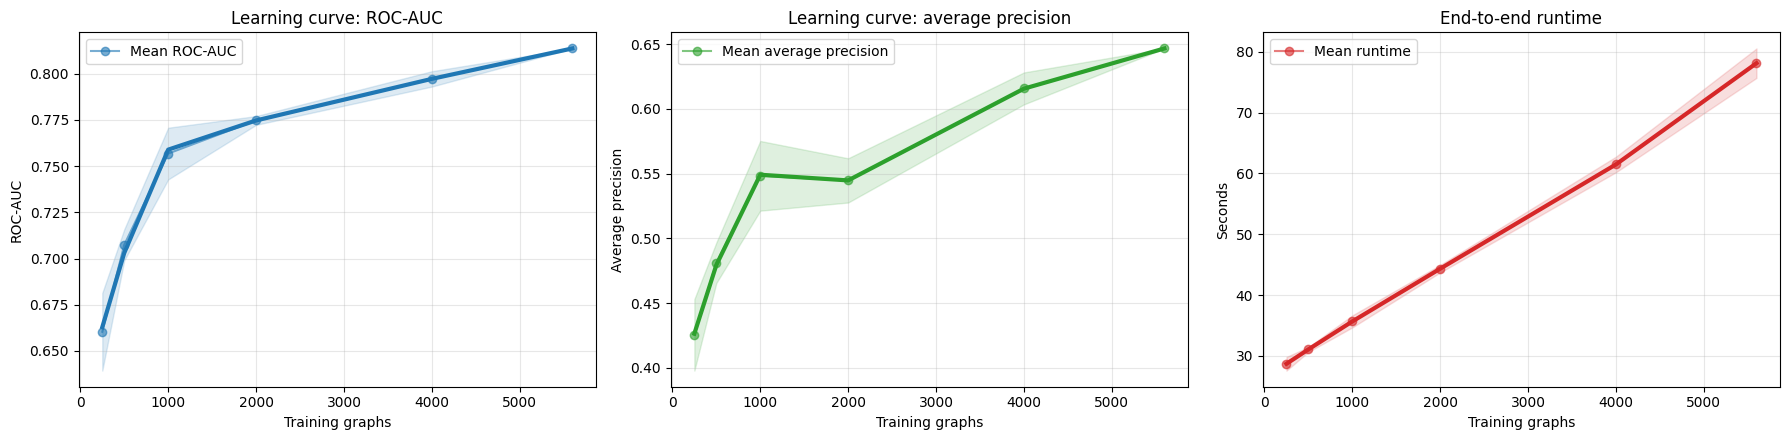

In [16]:
fig, axes = plt.subplots(1, 3, figsize=(18, 4.5))
frac = 0.8  # Local quadratic LOESS span; adjust between 0 and 1 for more or less smoothing.
x = results_df['train_size'].to_numpy()

plot_series_with_band_loess(
    axes[0],
    x,
    results_df['mean_roc_auc'],
    y_std=results_df['std_roc_auc'],
    frac=frac,
    label='Mean ROC-AUC',
)
axes[0].set_xlabel('Training graphs')
axes[0].set_ylabel('ROC-AUC')
axes[0].set_title('Learning curve: ROC-AUC')
axes[0].grid(True, alpha=0.3)
axes[0].legend()

plot_series_with_band_loess(
    axes[1],
    x,
    results_df['mean_avg_precision'],
    y_std=results_df['std_avg_precision'],
    frac=frac,
    color='tab:green',
    label='Mean average precision',
)
axes[1].set_xlabel('Training graphs')
axes[1].set_ylabel('Average precision')
axes[1].set_title('Learning curve: average precision')
axes[1].grid(True, alpha=0.3)
axes[1].legend()

plot_series_with_band_loess(
    axes[2],
    x,
    results_df['mean_runtime_sec'],
    y_std=results_df['std_runtime_sec'],
    frac=frac,
    color='tab:red',
    label='Mean runtime',
)
axes[2].set_xlabel('Training graphs')
axes[2].set_ylabel('Seconds')
axes[2].set_title('End-to-end runtime')
axes[2].grid(True, alpha=0.3)
axes[2].legend()

plt.tight_layout()
plt.show()
